## loading the data
## pls model on pre-processed data

use https://nirpyresearch.com/robust-pca/

then robust pls

# Robust analysis

## Loading the data

In [79]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]
reference_values = np.expand_dims(reference_values, axis=1)
reference_values.shape

(180, 1)

## Robust PCA

PCA is very susceptible to the outliers. If we modify just one sample the results already are going to be quite different.

In [80]:
import matplotlib.pyplot as plt
 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [81]:
X_copy = np.copy(kiwi_spectra)
X_copy[0,:] = X_copy[0,:]**3 +12*(X_copy[0,:])

In [82]:
pipe1 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA())])
pipe2 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA())])
 
pipe1.fit(kiwi_spectra)
pipe2.fit(X_copy)

Pipeline(steps=[('scaler', StandardScaler(with_std=False)), ('pca', PCA())])

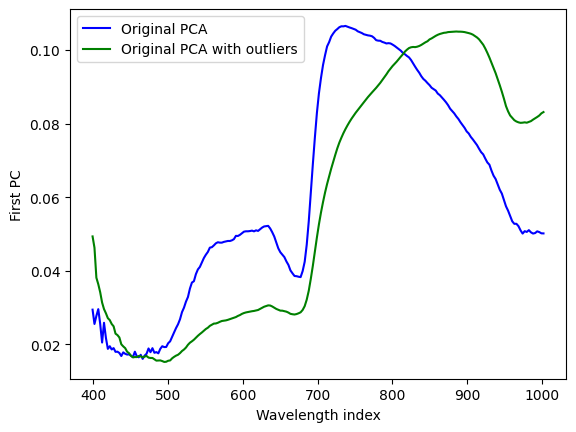

In [83]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

If we use robust way of estimating covariance (for example using `LedoitWolf` estimator), we can mitigate the effects of outliers

In [84]:
from sklearn.covariance import LedoitWolf

robust_cov = LedoitWolf().fit(X_copy)
V = robust_cov.covariance_
 
# Calculate eigenvalues and eigenvectors of the covariance matrix
values, vectors = np.linalg.eig(V)
 
# Sort eigenvalues in descending order
sorted_values = np.argsort(values)[::-1]
# Sort eigenvectors
sorted_vectors = vectors[:,sorted_values]

first_pc_robust = sorted_vectors[:, 0]
first_pc_robust /= np.linalg.norm(first_pc_robust)
first_pc_robust *= -1 # Eigenvectors are unique up to a sign. 

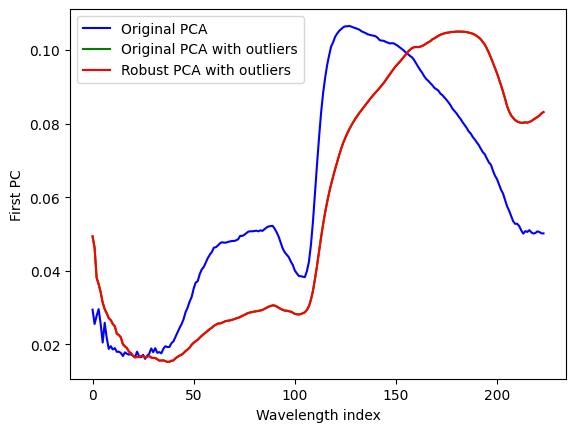

In [85]:
plt.plot(pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.plot(first_pc_robust, 'r', label="Robust PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()


## Robust PLSR

using https://github.com/puneetmishra2/IRNPLS/tree/main

In [88]:
import numpy as np
from scipy.sparse.linalg import svds
from scipy.stats import median_abs_deviation

def irpls(X, Y, lvs, alpha):
    """
    Iteratively Reweighted Partial Least Squares (IRPLS)
    
    Parameters:
    -----------
    X : array-like
        Predictor matrix
    Y : array-like
        Response matrix
    lvs : int
        Number of latent variables
    alpha : float
        Tuning parameter for robust estimation
    
    Returns:
    --------
    crbvar : array
        Cumulative variance explained in Y
    beta : list
        Regression coefficients for each response variable
    weights : array
        Weights matrix
    attributes : dict
        Dictionary containing T, Pb, W, PtW matrices
    """
    
    # Convert inputs to numpy arrays
    X = np.array(X)
    Y = np.array(Y)
    
    # Handle reshaping for multi-dimensional X
    dims = X.shape
    if len(dims) > 2:
        X = X.reshape(dims[0], np.prod(dims[1:]))
    
    # Save original matrices
    Xorig = X.copy()
    yorig = Y.copy()
    
    # Median centering
    X2 = X - np.median(X, axis=0)
    X = X - np.median(X, axis=0)
    Y = Y - np.median(Y, axis=0)
    
    # Ensure Y is 2D
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)
    
    # Pre-allocations
    q = np.zeros((Y.shape[1], lvs))
    T = np.zeros((Y.shape[0], lvs))
    crbvar = np.zeros(lvs)
    vartot = np.sum(Y**2)
    weights = np.zeros((lvs, X.shape[0]))
    w = np.zeros((X.shape[1], lvs))
    Pb = np.zeros((X.shape[1], lvs))
    
    # Main loop for selecting variables
    for i in range(lvs):
        # Initialize diagonal weight matrix
        D = np.eye(X.shape[0]) * (1/X.shape[0])
        crit = 1
        
        # Iterative reweighting loop
        while crit > 1e-5:
            vt = X.T @ D @ Y
            
            # Handle multi-dimensional case
            if len(dims) > 2:
                vt = vt.reshape(dims[1:])
                # Use SVD for dimensionality reduction
                if vt.ndim > 1:
                    U, s, Vt = svds(vt, k=1)
                    wjx = U.flatten()
                    wkx = Vt.flatten()
                    v = np.kron(wkx, wjx)
                else:
                    v = vt.flatten()
            else:
                v = vt.flatten()
            
            # Calculate scores
            Xv = X @ v
            t_temp = Xv / np.linalg.norm(Xv)
            
            # Calculate regression coefficients
            q_temp = (Y.T @ D) @ t_temp
            
            # Calculate residuals
            r = Y - np.outer(t_temp, q_temp)
            
            # Leverage calculation
            lo = 1 - np.diag(np.outer(t_temp, t_temp))
            
            # Robust residual calculation
            r = r / np.sqrt(lo).reshape(-1, 1)
            
            # Calculate MAD for each column of r
            mad_r = np.array([median_abs_deviation(r[:, j], axis=0) for j in range(r.shape[1])])
            r = r * (0.6745/alpha) / mad_r
            
            # Calculate weights
            temp_D = (1 - r**2)**2
            temp_D[np.abs(r) >= 1] = 0
            temp_D = np.prod(temp_D, axis=1)
            
            # Check convergence
            crit = np.sum(np.abs(temp_D - np.diag(D)))
            D = np.diag(temp_D)
        
        # Store weights
        weights[i, :] = np.diag(D)
        
        # Final calculation for this component
        vt = X.T @ D @ Y
        
        if len(dims) > 2:
            vt = vt.reshape(dims[1:])
            if vt.ndim > 1:
                U, s, Vt = svds(vt, k=1)
                wjx = U.flatten()
                wkx = Vt.flatten()
                w[:, i] = np.kron(wkx, wjx)
            else:
                w[:, i] = vt.flatten()
        else:
            w[:, i] = vt.flatten()
        
        # Calculate scores
        Xw = X @ w[:, i]
        t = Xw / np.linalg.norm(Xw)
        t = t / np.linalg.norm(t)  # Normalize
        T[:, i] = t
        
        # Calculate regression coefficients
        q[:, i] = (Y.T @ D) @ t
        Pb[:, i] = (X.T @ D) @ t
        
        # Deflation
        X = X - np.outer(t, Pb[:, i])
        Y = Y - np.outer(t, q[:, i])
        
        # Normalize weights
        w[:, i] = w[:, i] / np.linalg.norm(w[:, i])
        
        # Calculate explained variance
        crbvar[i] = (vartot - np.sum(Y**2)) / vartot
    
    # Post-processing for regression coefficients
    PtW = np.triu(Pb.T @ w)
    beta = []
    
    # Handle case where Y was originally 1D
    if yorig.ndim == 1:
        yorig = yorig.reshape(-1, 1)
    
    for i in range(yorig.shape[1]):
        # Calculate regression coefficients
        # Use matrix solve instead of division for better numerical stability
        beta_i = np.zeros((w.shape[0], lvs))
        for j in range(lvs):
            if j == 0:
                beta_i[:, j] = (w[:, j] / PtW[j, j]) * q[i, j]
            else:
                beta_i[:, j] = beta_i[:, j-1] + (w[:, j] / PtW[j, j]) * q[i, j]
        
        # Add intercept for each latent variable
        intercepts = np.zeros(lvs)
        for j in range(lvs):
            intercepts[j] = np.median(yorig[:, i]) - np.median(Xorig, axis=0) @ beta_i[:, j]
        
        # Combine intercepts and coefficients
        beta_i = np.vstack([intercepts.reshape(1, -1), beta_i])
        beta.append(beta_i)
    
    # Create attributes dictionary
    attributes = {
        'T': T,
        'Pb': Pb,
        'W': w,
        'PtW': PtW
    }
    
    return crbvar, beta, weights, attributes

Training samples: 144
Test samples: 36
----------------------------------------
Running IRPLS...
Beta length: 1
Beta[0] shape: (225, 14)
Beta[0] has NaN: False
Beta[0] has Inf: False
IRPLS - RMSE: 3.9597, R²: -17.2099
Running Normal PLSR...
PLSR  - RMSE: 0.7378, R²: 0.3679
----------------------------------------


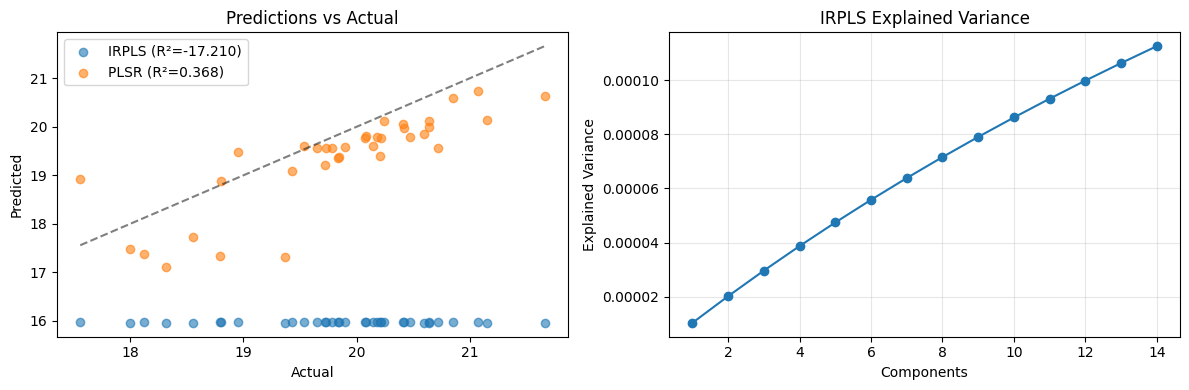

SUMMARY:
✓ PLSR has lower RMSE (0.7378 vs 3.9597)
✓ PLSR has higher R² (0.3679 vs -17.2099)


In [99]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import nippy

def robust_irpls_predict(X_test, beta, X_train, Y_train, component_idx=-1):
    """
    Robust prediction function for IRPLS that handles edge cases
    """
    try:
        # Handle empty beta
        if not beta or len(beta) == 0:
            print("Warning: Empty beta, using mean prediction")
            return np.full(len(X_test), np.mean(Y_train))
        
        # Get coefficients for first response
        beta_matrix = beta[0]
        
        # Check for valid component index
        if component_idx == -1:
            component_idx = beta_matrix.shape[1] - 1
        
        if component_idx >= beta_matrix.shape[1]:
            component_idx = beta_matrix.shape[1] - 1
            
        # Extract coefficients
        intercept = beta_matrix[0, component_idx]
        coefficients = beta_matrix[1:, component_idx]
        
        # Check for NaN/Inf
        if np.isnan(intercept) or np.isinf(intercept):
            print("Warning: Invalid intercept, using median Y")
            intercept = np.median(Y_train)
            
        if np.isnan(coefficients).any() or np.isinf(coefficients).any():
            print("Warning: Invalid coefficients, using zero coefficients")
            coefficients = np.zeros_like(coefficients)
        
        # Center test data the same way as training
        X_test_centered = X_test - np.median(X_train, axis=0)
        
        # Make prediction
        Y_pred = intercept + X_test_centered @ coefficients
        
        # Final check for NaN/Inf in predictions
        if np.isnan(Y_pred).any() or np.isinf(Y_pred).any():
            print("Warning: Invalid predictions, using mean prediction")
            return np.full(len(X_test), np.mean(Y_train))
            
        return Y_pred
        
    except Exception as e:
        print(f"Prediction failed: {e}, using mean prediction")
        return np.full(len(X_test), np.mean(Y_train))

def simple_comparison(X, Y, n_components=10, wl=wl):
    """
    Simple comparison between IRPLS and normal PLSR
    """
    preprocessing_pipeline = {'MSC': None, 
                          'SAVGOL': 
                          {'deriv_order': 2, 
                           'filter_win': 13, 
                           'poly_order': 2}, 
                           'SNV': {}}

    wl, X_processed = nippy.run_pipeline(wl, X.T, preprocessing_pipeline)
    X_processed = X_processed.T

    # Split data: 80% train, 20% test
    n_train = int(0.8 * len(X_processed))
    X_train, X_test = X_processed[:n_train], X_processed[n_train:]
    Y_train, Y_test = Y[:n_train], Y[n_train:]

    n_components = 14

    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))
    print("-" * 40)
    
    # 1. IRPLS
    print("Running IRPLS...")
    try:
        crbvar, beta, weights, attributes = irpls(X_train, Y_train, n_components, alpha=0.01)
        
        # Debug: Check beta structure
        print(f"Beta length: {len(beta)}")
        if len(beta) > 0:
            print(f"Beta[0] shape: {beta[0].shape}")
            print(f"Beta[0] has NaN: {np.isnan(beta[0]).any()}")
            print(f"Beta[0] has Inf: {np.isinf(beta[0]).any()}")
        
        # Use robust prediction function
        Y_pred_irpls = robust_irpls_predict(X_test, beta, X_train, Y_train)
            
    except Exception as e:
        print(f"IRPLS failed: {e}")
        # Fallback prediction
        Y_pred_irpls = np.full(len(X_test), np.mean(Y_train))
    
    # Metrics
    rmse_irpls = root_mean_squared_error(Y_test, Y_pred_irpls)
    r2_irpls = r2_score(Y_test, Y_pred_irpls)
    
    print(f"IRPLS - RMSE: {rmse_irpls:.4f}, R²: {r2_irpls:.4f}")
    
    # 2. Normal PLSR
    print("Running Normal PLSR...")
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train, Y_train)
    Y_pred_pls = pls.predict(X_test).flatten()
    
    # Metrics
    rmse_pls = root_mean_squared_error(Y_test, Y_pred_pls)
    r2_pls = r2_score(Y_test, Y_pred_pls)
    
    print(f"PLSR  - RMSE: {rmse_pls:.4f}, R²: {r2_pls:.4f}")
    print("-" * 40)
    
    # 3. Simple plot
    plt.figure(figsize=(12, 4))
    
    # Plot 1: Predictions vs Actual
    plt.subplot(1, 2, 1)
    plt.scatter(Y_test, Y_pred_irpls, alpha=0.6, label=f'IRPLS (R²={r2_irpls:.3f})')
    plt.scatter(Y_test, Y_pred_pls, alpha=0.6, label=f'PLSR (R²={r2_pls:.3f})')
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', alpha=0.5)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predictions vs Actual')
    plt.legend()
    
    # Plot 2: Explained variance
    plt.subplot(1, 2, 2)
    components_range = range(1, len(crbvar) + 1)
    plt.plot(components_range, crbvar, 'o-', label='IRPLS Explained Variance')
    plt.xlabel('Components')
    plt.ylabel('Explained Variance')
    plt.title('IRPLS Explained Variance')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Summary
    print("SUMMARY:")
    if rmse_irpls < rmse_pls:
        print(f"✓ IRPLS has lower RMSE ({rmse_irpls:.4f} vs {rmse_pls:.4f})")
    else:
        print(f"✓ PLSR has lower RMSE ({rmse_pls:.4f} vs {rmse_irpls:.4f})")
    
    if r2_irpls > r2_pls:
        print(f"✓ IRPLS has higher R² ({r2_irpls:.4f} vs {r2_pls:.4f})")
    else:
        print(f"✓ PLSR has higher R² ({r2_pls:.4f} vs {r2_irpls:.4f})")
    
    return {
        'irpls': {'rmse': rmse_irpls, 'r2': r2_irpls},
        'plsr': {'rmse': rmse_pls, 'r2': r2_pls}
    }

# Usage:
results = simple_comparison(X_copy, reference_values, n_components=14)

crbvar: Cumulative variance explained by each latent variable

beta: List of regression coefficient matrices (with intercepts)

weights: Diagonal weights from each iteration

attributes: Dictionary with:

T: Scores

Pb: Loadings

W: Weight vectors

PtW: Transformation matrix (used for projection)